In [2]:
using DriftDiffusionModels
using CSV
using DataFrames
using Distributions
using Plots
using Random
using StatsPlots
using StatsBase
using Statistics

In [3]:
results_dir = "../results/"

# file paths
elbo_csv = "eddm_elbo_history_by_rat.csv"
trial_post_csv = "eddm_trial_posteriors_by_rat.csv.gz"
hyper_csv = "eddm_hyperparams_by_rat.csv"

# load data into DataFrames
elbo_df = CSV.read(results_dir * elbo_csv, DataFrame)
trial_post_df = CSV.read(results_dir * trial_post_csv, DataFrame)
hyper_df = CSV.read(results_dir * hyper_csv, DataFrame)

Row,rat_name,m_uB,m_uτ,m_uv,m_ua0,logσ0_uB,logσ0_uτ,logσ0_uv,logσ0_ua0,B_group_mean,τ_group_mean,v_group_mean,a0_group_mean
,String7,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Denna,0.508414,-0.372245,-0.876991,0.115254,-1.46626,-2.36661,-0.499769,-1.25393,1.66265,0.689185,0.416033,0.528782
2,Dopey,0.44076,-0.325968,-0.787446,-0.15591,-1.67914,-2.13725,-0.490043,-1.27341,1.55389,0.721828,0.455005,0.461101
3,Draco,0.368197,-0.549781,-0.643003,-0.4083,-1.54813,-2.38398,-0.587655,-1.32556,1.44513,0.577076,0.525711,0.39932
4,Randy,0.500179,-0.453652,-0.318211,-0.470805,-1.74996,-2.28396,-0.621957,-1.35668,1.64902,0.635304,0.72745,0.384426
5,Remy,0.325738,-0.661258,-0.470534,-0.361433,-1.69892,-1.97331,-0.693089,-1.30789,1.38505,0.516202,0.624669,0.410613
6,Rhea,0.481352,-0.453875,-0.51659,-0.277232,-1.60898,-1.95765,-0.673148,-1.29469,1.61826,0.635162,0.596551,0.431132
7,Robert,0.530627,-0.732575,-0.639243,0.399873,-1.71229,-1.82715,-0.552589,-1.28667,1.7,0.48067,0.527691,0.598657
8,Ron,0.389696,-0.673733,-0.575903,-0.311881,-1.65679,-2.02577,-0.523066,-1.29657,1.47653,0.509802,0.562197,0.422656
9,Rudy,0.438755,-0.577443,-0.973976,-0.0904594,-1.7519,-1.80727,-0.494441,-1.23928,1.55078,0.561332,0.377579,0.477401


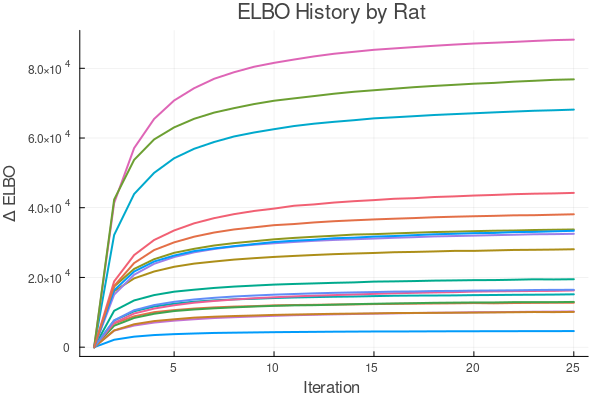

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\notebooks\\eddm_elbo_history_by_rat.svg"

In [4]:
# plot the ELBOs so we can confirm models converged
grouped_elbo = groupby(elbo_df, :rat_name)
plt = plot(title="ELBO History by Rat", xlabel="Iteration", ylabel="Δ ELBO")
for g in grouped_elbo
    rat_name = unique(g.rat_name)[1]
    plot!(plt, g.iter, g.elbo .- minimum(g.elbo), fontfamily="helvetica", label=rat_name, lw=2, legend=false)
end
display(plt)

savefig(plt, "eddm_elbo_history_by_rat.svg")

In [5]:
# make a plot of the hyperparameters across rats
plot(legend=false; fontfamily="helvetica")
@df hyper_df boxplot!(["Bμ" for i in 1:nrow(hyper_df)], :B_group_mean)
@df hyper_df boxplot!(["τμ" for i in 1:nrow(hyper_df)], :τ_group_mean)
@df hyper_df boxplot!(["vμ" for i in 1:nrow(hyper_df)], :v_group_mean)
@df hyper_df boxplot!(["a0μ" for i in 1:nrow(hyper_df)], :a0_group_mean)

@df hyper_df dotplot!(["Bμ" for i in 1:nrow(hyper_df)], :B_group_mean)
@df hyper_df dotplot!(["τμ" for i in 1:nrow(hyper_df)], :τ_group_mean)
@df hyper_df dotplot!(["vμ" for i in 1:nrow(hyper_df)], :v_group_mean)
@df hyper_df dotplot!(["a0μ" for i in 1:nrow(hyper_df)], :a0_group_mean)

ylabel!("θ")
title!("eDDM Rat Hyperparameters")

savefig("eddm_hyperparams_by_rat.svg")

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\notebooks\\eddm_hyperparams_by_rat.svg"

In [ ]:
# get autocorrlation of each of the trial parameters per rat
rats = unique(trial_post_df.rat_name)

function rat_acf(rat_name::String7, max_lag::Int = 20)
    sub_df = filter(row -> row.rat_name == rat_name, trial_post_df)
    acf_dict = DataFrame(
        Dict(
        "B_acf" => autocor(sub_df.B_mean, 1:max_lag),
        "τ_acf" => autocor(sub_df.τ_mean, 1:max_lag),
        "v_acf" => autocor(sub_df.v_mean, 1:max_lag),
        "a0_acf" => autocor(sub_df.a0_mean, 1:max_lag),
    )
    )

    return acf_dict
end

acfs = Vector{DataFrame}(undef, length(rats))

for (i, rat) in enumerate(rats)
    acfs[i] = rat_acf(rat)
end

# one df 
combined = vcat(
    (hcat(df, DataFrame(rat = fill(rat, nrow(df))))
     for (df, rat) in zip(acfs, rats))...;
    cols = :union,
)

combined.lag = repeat(1:20, length(rats))

mean_acf = combine(groupby(combined, :lag),
    :B_acf => mean,
    :a0_acf => mean,
    :v_acf => mean,
    :τ_acf => mean
)

sem_acf = combine(groupby(combined, :lag),
    :B_acf => (x -> std(x) / sqrt(length(x))) => :B_acf_sem,
    :a0_acf => (x -> std(x) / sqrt(length(x))) => :a0_acf_sem,
    :v_acf => (x -> std(x) / sqrt(length(x))) => :v_acf_sem,
    :τ_acf => (x -> std(x) / sqrt(length(x))) => :τ_acf_sem
)



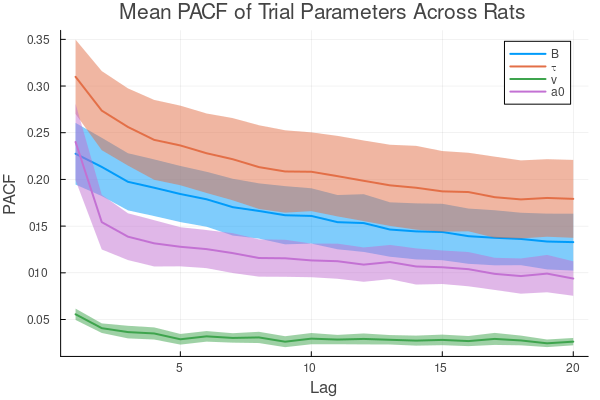

In [ ]:
p = plot(title="Mean acf of Trial Parameters Across Rats", xlabel="Lag", ylabel="acf", fontfamily="helvetica")

plot!(p, mean_acf.lag, mean_acf.B_acf_mean,
    ribbon=1.96 * sem_acf.B_acf_sem,
    label="B",
    lw=2,
)

plot!(p, mean_acf.lag, mean_acf.τ_acf_mean,
    ribbon=1.96 *sem_acf.τ_acf_sem,
    label="τ",
    lw=2,
)

plot!(p, mean_acf.lag, mean_acf.v_acf_mean,
    ribbon=1.96 *sem_acf.v_acf_sem,
    label="v",
    lw=2,
)

plot!(p, mean_acf.lag, mean_acf.a0_acf_mean,
    ribbon=1.96 * sem_acf.a0_acf_sem,
    label="a0",
    lw=2,
)

savefig(p, results_dir * "eddm_trial_param_acf.svg")

In [42]:
function acf_rts(rat::String7, maxlags=20)
    sub_df = filter(row -> row.rat_name == rat, trial_post_df)
    rts = sub_df.rt
    acf_vals = autocor(rts, 1:maxlags)
    acf_df = DataFrame(RT_acf = acf_vals)
    return acf_df
end

acf_vals = Vector{DataFrame}(undef, length(rats))

for (i, rat) in enumerate(rats)
    acf_vals[i] = acf_rts(rat, 20)
end     

# one df 
combined_rt = vcat(
    (hcat(df, DataFrame(rat = fill(rat, nrow(df))))
     for (df, rat) in zip(acf_vals, rats))...;
    cols = :union,
)

combined_rt.lag = repeat(1:20, length(rats))

mean_acf = combine(groupby(combined_rt, :lag),
    :RT_acf => mean,
)

sem_acf = combine(groupby(combined_rt, :lag),
    :RT_acf => (x -> std(x) / sqrt(length(x))) => :RT_acf_sem
)



Row,lag,RT_acf_sem
,Int64,Float64
1,1,0.0121147
2,2,0.0108192
3,3,0.0104039
4,4,0.0108899
5,5,0.0102199
6,6,0.00977133
7,7,0.0103876
8,8,0.00960434
9,9,0.010489


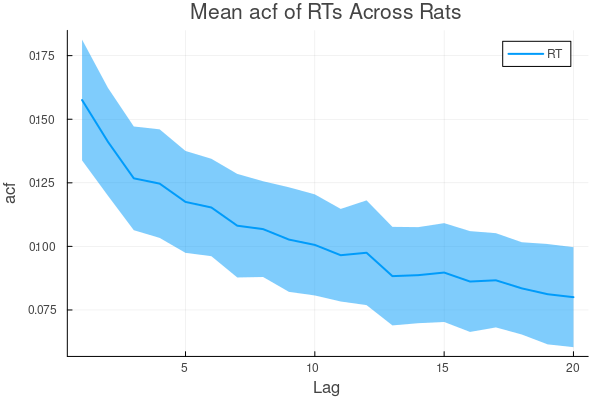

In [43]:
rt_acf = plot(title="Mean acf of RTs Across Rats", xlabel="Lag", ylabel="acf", fontfamily="helvetica")

plot!(rt_acf, mean_acf.lag, mean_acf.RT_acf_mean;
    ribbon=1.96 * sem_acf.RT_acf_sem,
    label="RT",
    lw=2,
)

# savefig(rt_acf, results_dir * "rt_acf.svg")

In [ ]:
acf_vec(x::AbstractVector{<:Real}, maxlag::Int) =
    autocor(collect(x), 0:maxlag)  # lags 0..maxlag

function params_for_rat(df_params::DataFrame, rat::AbstractString)
    row = only(df_params[df_params.rat_name .== rat, :])
    return (B=row.B_group_mean, v=row.v_group_mean, a0=row.a0_group_mean, τ=row.τ_group_mean)
end

function sim_ddm_trial(rng::AbstractRNG, B, v, a0, τ;
                       dt=1e-4, tmax=5.0, drift_sign::Float64=1.0)
    x = a0 * B
    t = 0.0
    μ = drift_sign * v

    while t < tmax
        x += μ * dt + sqrt(dt) * randn(rng)
        t += dt
        if x >= B
            return (τ + t, 1)
        elseif x <= 0.0
            return (τ + t, 0)
        end
    end
    return (NaN, NaN)
end

function sim_rts_symmetric(rng::AbstractRNG, B, v, a0, τ, N::Int;
                           dt=1e-4, tmax=5.0)
    rts = Vector{Float64}(undef, N)
    n_timeout = 0
    for t in 1:N
        sign = rand(rng, Bool) ? 1.0 : -1.0
        rt, _ = sim_ddm_trial(rng, B, v, a0, τ; dt=dt, tmax=tmax, drift_sign=sign)
        rts[t] = rt
        n_timeout += !isfinite(rt) ? 1 : 0
    end
    good = isfinite.(rts)
    return rts[good], n_timeout / N
end

"""
PPC for population mean RT ACF under the fitted (symmetric) eDDM.

Inputs
- df_params: rat-level params (rat_name, B_group_mean, v_group_mean, a0_group_mean, τ_group_mean)
- N_by_rat: Function (rat_name::String)->Int OR Dict{String,Int}
- maxlag: max ACF lag
- Brep: number of PPC replicates
- dt, tmax: simulator controls

Returns NamedTuple with:
- lag      :: Vector{Int}          (0:maxlag)
- acf_mean :: Vector{Float64}      (mean across PPC replicates of population mean ACF)
- acf_lo   :: Vector{Float64}      (2.5% band across PPC replicates)
- acf_hi   :: Vector{Float64}      (97.5% band across PPC replicates)
- acf_reps :: Matrix{Float64}      (Brep × (maxlag+1)) population mean ACF per replicate
- timeout_rate_by_rat :: Dict{String,Float64} avg timeout rate per rat across replicates
- rats     :: Vector{String}
"""
function ppc_population_acf(df_params::DataFrame, N_by_rat;
                            maxlag::Int=20,
                            Brep::Int=300,
                            rng::AbstractRNG=MersenneTwister(1),
                            dt::Float64=1e-4,
                            tmax::Float64=5.0)

    rats = collect(df_params.rat_name)
    sort!(rats)
    R = length(rats)
    R == 0 && error("df_params has no rats.")

    getN = N_by_rat isa Function ? N_by_rat :
           N_by_rat isa AbstractDict ? (rat -> N_by_rat[rat]) :
           error("N_by_rat must be a Function or a Dict{String,Int}.")

    # store population mean ACF per replicate
    acf_reps = Matrix{Float64}(undef, Brep, maxlag+1)

    # timeout diagnostics
    timeout_sum = Dict(rat => 0.0 for rat in rats)

    for b in 1:Brep
        # rat-level ACFs for this replicate
        rat_acf = Matrix{Float64}(undef, R, maxlag+1)

        for (i, rat) in enumerate(rats)
            p = params_for_rat(df_params, rat)
            N = getN(rat)

            rts, to = sim_rts_symmetric(rng, p.B, p.v, p.a0, p.τ, N; dt=dt, tmax=tmax)
            timeout_sum[rat] += to

            if length(rts) <= maxlag + 2
                rat_acf[i, :] .= NaN
            else
                rat_acf[i, :] .= acf_vec(rts, maxlag)
            end
        end

        # population mean ACF for this replicate (skip NaNs if any)
        for k in 1:(maxlag+1)
            col = rat_acf[:, k]
            good = isfinite.(col)
            acf_reps[b, k] = mean(col[good])
        end
    end

    acf_mean = vec(mean(acf_reps; dims=1))
    acf_lo   = [quantile(acf_reps[:, k], 0.025) for k in 1:(maxlag+1)]
    acf_hi   = [quantile(acf_reps[:, k], 0.975) for k in 1:(maxlag+1)]

    timeout_rate_by_rat = Dict(rat => timeout_sum[rat] / Brep for rat in rats)

    return (lag=collect(1:maxlag),
            acf_mean=acf_mean,
            acf_lo=acf_lo,
            acf_hi=acf_hi,
            acf_reps=acf_reps,
            timeout_rate_by_rat=timeout_rate_by_rat,
            rats=rats)
end

ppc = ppc_population_acf(hyper_df, rat -> 2000; maxlag=20, Brep=400, tmax=8.0)

(lag = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9  …  11, 12, 13, 14, 15, 16, 17, 18, 19, 20], acf_mean = [1.0, -0.0008141005624811968, -0.0004937989169343516, -0.00045493506316315776, -0.000756836783445115, -0.0005362984545939049, -5.829695657217251e-5, -0.0005628747814962259, -0.00045602792011894205, -0.0003666766297078135  …  -0.0004723639037035197, -0.0012126347402562395, -0.0005870876254419724, -0.000742450965594576, -0.0004161374256999287, -0.0008547775507998644, -0.0004439730328347611, 1.4744543356940851e-6, -9.394469059709688e-5, -0.0007282638025499652], acf_lo = [1.0, -0.011807372212174524, -0.010614922672644963, -0.010530336673982265, -0.01044294984902527, -0.0106373620292422, -0.010801268864224953, -0.010660656692769065, -0.00945698292585127, -0.009802807987684063  …  -0.010951898806040876, -0.011836574022685191, -0.010313676952403098, -0.011337220743813745, -0.010734827295163176, -0.011656155638829616, -0.00900601061797887, -0.009865267527322695, -0.010130640068033376, -0.01026551261554

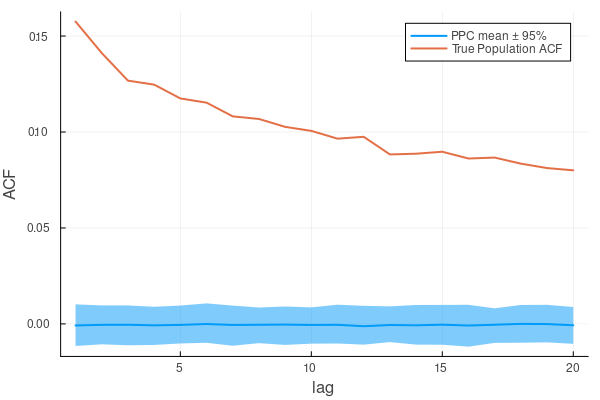

In [51]:
upper = ppc.acf_hi .- ppc.acf_mean
lower = ppc.acf_mean .- ppc.acf_lo

p = plot(;fontfamily="helvetica", xlabel="lag" , ylabel="ACF")

plot!(ppc.lag[2:end], ppc.acf_mean[2:end];
     ribbon=(upper[2:end], lower[2:end]),
     label="PPC mean ± 95%",
     lw=2)
     
plot!(mean_acf.lag, mean_acf.RT_acf_mean;
    label="True Population ACF",
    lw=2,
)

